# FTCS Test (The test/plotting was written by AI)

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from FTCS import FTCS

def exact_solution(x, t, c, central_pos, magnitude, std):
    return magnitude * np.exp(-(x - central_pos - c * t)**2 / (2 * std**2))

In [24]:
dt = 0.1
total_time = 200.0
steps = int(round(total_time / dt))

Wave_list = {
    "wave_speed": 0.2,
    "std": 2.0,
    "magnitude": 1.0,
    "central_pos": 20.0,
    "grid_length": 100.0,
    "dt": dt,
    "cell_amt": 1000,
}

x, times, u_hist = FTCS(Wave_list, dt=dt, total_time=total_time,
                        wave_speed=Wave_list['wave_speed'], steps=steps)

c  = Wave_list['wave_speed']
ds = Wave_list['grid_length'] / Wave_list['cell_amt']
print("Courant number:", c * dt / ds)
print("u_hist shape:", u_hist.shape)

Courant number: 0.20000000000000004
u_hist shape: (2001, 1000)


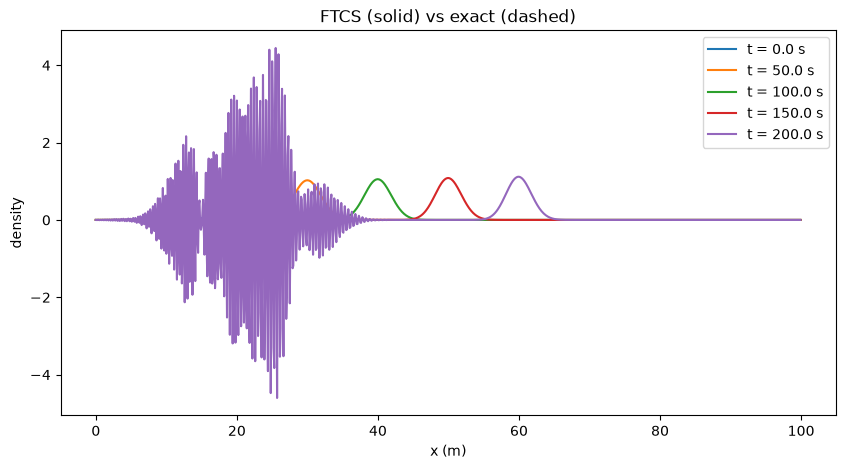

In [ ]:
def exact(t):
    return exact_solution(x, t, c, Wave_list['central_pos'],
                          Wave_list['magnitude'], Wave_list['std'])

plt.figure(figsize=(10, 5))
for k in np.linspace(0, len(times) - 1, 5, dtype=int):
    plt.plot(x, u_hist[k], label=f"t = {times[k]:.1f} s")
    plt.plot(x, exact(times[k]), 'k--', lw=0.8)
plt.xlabel("x (m)")
plt.ylabel("density")
plt.title("FTCS (solid) vs exact (dashed)")
plt.legend()
plt.show()

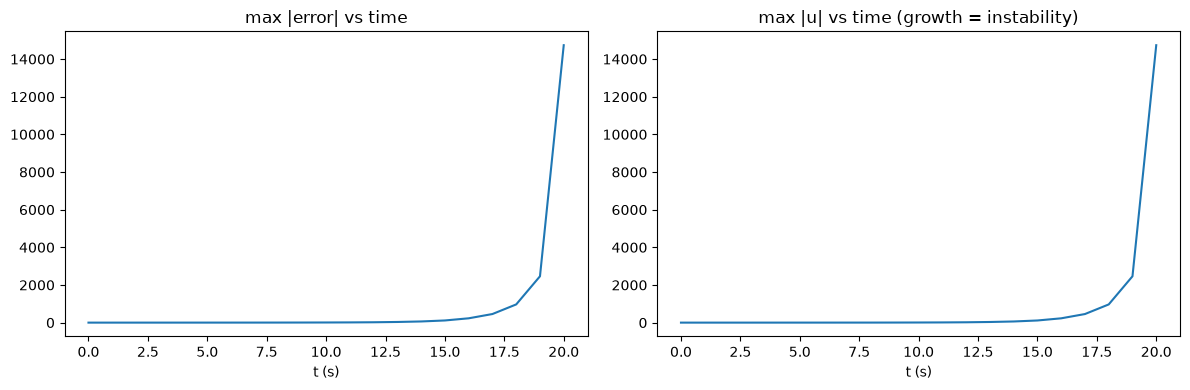

In [19]:
err_max = [np.max(np.abs(u_hist[k] - exact(times[k]))) for k in range(len(times))]
u_max = np.max(np.abs(u_hist), axis=1)

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(times, err_max)
axs[0].set_title("max |error| vs time")
axs[1].plot(times, u_max)
axs[1].set_title("max |u| vs time (growth = instability)")
for a in axs:
    a.set_xlabel("t (s)")
plt.tight_layout()
plt.show()